In [1]:
import json
import numpy as np
import pyvisa
import time
import hid # pip install hidapi
import skrf as rf
import matplotlib.pyplot as plt
import serial.tools.list_ports
from RsInstrument import RsInstrument, BinFloatFormat
from datetime import datetime
from pathlib import Path
import os
import sys
import matplotlib.colors as mcolors
from urllib.request import urlopen

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

PROGRAMMABLE_ATTENUATOR_IP_ADDRESS = '169.254.11.11'
def get_attenuation_state(ip_address):
    # The direct URL that successfully delivers the information
    url = f"http://{ip_address}/ATT?"
    
    try:
        with urlopen(url, timeout=2.0) as response:
            # Read bytes, decode to string, and remove whitespace/newlines
            attenuation_value = response.read().decode('utf-8').strip()
            return float(attenuation_value)
            
    except URLError as e:
        print(f"Connection failed: {e.reason}")
        return None
    except ValueError:
        print(f"Parsing Error: Could not convert response to number: {attenuation_value}")
        return None

yoko = None
for instrument in instruments:
    if 'YOKOGAWA' in instrument:
        # Initialize instrument
        yoko = rm.open_resource(instrument) 
        break
vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break
print(vna.query('*IDN?').strip())
arb = None
for instrument in instruments:
    if '33220A' in instrument:
        # Initialize instrument
        arb = rm.open_resource(instrument) 
        break
print(arb.query('*IDN?').strip())
arb.write("SYSTem:LOCal")
vna.go_to_local()

arb.write("FUNCtion DC")
noise_source_voltage = 0.0
arb.write(f"VOLTage:OFFSet {noise_source_voltage}")
arb.write("OUTPut ON")


Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30
Agilent Technologies,33220A,MY44053372,2.07-2.06-22-2


11

-35.0
-34.91
-34.81
-34.72
-34.62
-34.53
-34.43
-34.34
-34.25
-34.15
-34.06
-33.96
-33.87
-33.77
-33.68
-33.58
-33.49
-33.4
-33.3
-33.21
-33.11
-33.02
-32.92
-32.83
-32.74
-32.64
-32.55
-32.45
-32.36
-32.26
-32.17
-32.08
-31.98
-31.89
-31.79
-31.7
-31.6
-31.51
-31.42
-31.32
-31.23
-31.13
-31.04
-30.94
-30.85
-30.75
-30.66
-30.57
-30.47
-30.38
-30.28
-30.19
-30.09
-30.0
-29.91
-29.81
-29.72
-29.62
-29.53
-29.43
-29.34
-29.25
-29.15
-29.06
-28.96
-28.87
-28.77
-28.68
-28.58
-28.49
-28.4
-28.3
-28.21
-28.11
-28.02
-27.92
-27.83
-27.74
-27.64
-27.55
-27.45
-27.36
-27.26
-27.17
-27.08
-26.98
-26.89
-26.79
-26.7
-26.6
-26.51
-26.42
-26.32
-26.23
-26.13
-26.04
-25.94
-25.85
-25.75
-25.66
-25.57
-25.47
-25.38
-25.28
-25.19
-25.09
-25.0
-24.91
-24.81
-24.72
-24.62
-24.53
-24.43
-24.34
-24.25
-24.15
-24.06
-23.96
-23.87
-23.77
-23.68
-23.58
-23.49
-23.4
-23.3
-23.21
-23.11
-23.02
-22.92
-22.83
-22.74
-22.64
-22.55
-22.45
-22.36
-22.26
-22.17
-22.08
-21.98
-21.89
-21.79
-21.7
-21.6
-21.51
-21.42


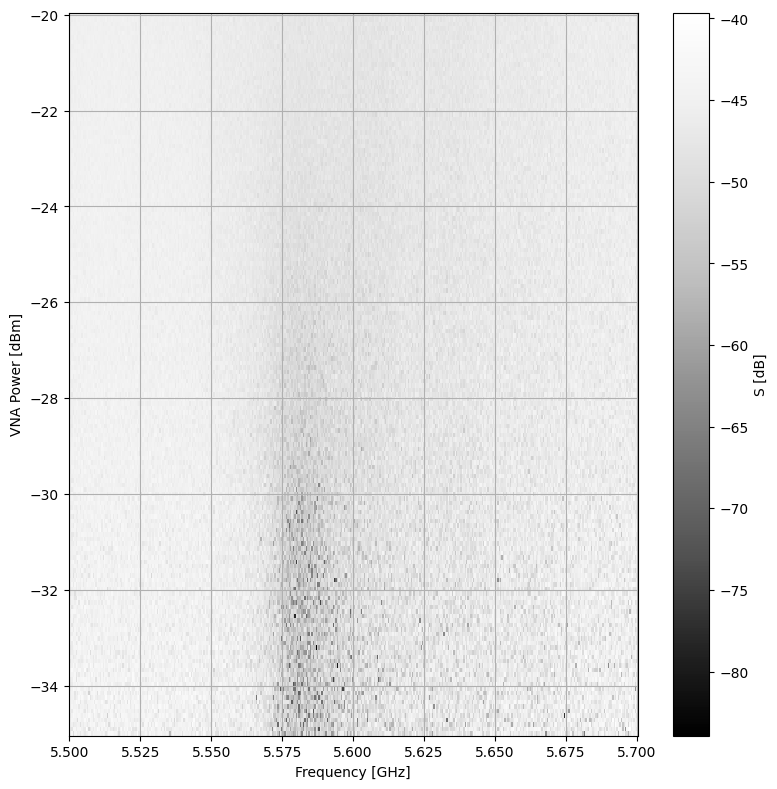

In [6]:
qubit_power_sweep = {}
power_sweep_start = -35
power_sweep_stop = -20
power_sweep_number_of_points = 160
noise_source_voltage = 0.0
qubit_power_sweep['flux_bias'] = 0.61
yoko.write(f":SOUR:LEV {qubit_power_sweep['flux_bias']:.4f}")

qubit_power_sweep['power_sweep'] = np.linspace(power_sweep_start, power_sweep_stop, power_sweep_number_of_points)
qubit_power_sweep['power_sweep'] = np.round(qubit_power_sweep['power_sweep']*100)/100
qubit_power_sweep['power_sweep'] = qubit_power_sweep['power_sweep'].tolist()

qubit_power_sweep['noise_source_voltage'] = noise_source_voltage
arb.write(f"VOLTage:OFFSet {noise_source_voltage}")


try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
folder_name = datetime.now().strftime("%d-%m-%Y")
target_dir = script_dir / folder_name
target_dir.mkdir(parents=True, exist_ok=True)

now = datetime.now().astimezone()
qubit_power_sweep['timestamp'] = int(now.timestamp())
qubit_power_sweep['date'] = now.strftime("%d-%m-%Y")
qubit_power_sweep['time'] = now.strftime("%H:%M:%S")
qubit_power_sweep['timezone'] = now.tzname()
qubit_power_sweep['temperature'] = '0.017'
qubit_power_sweep['start_time'] = int(now.timestamp())

readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + qubit_power_sweep['date'] + " Plots\n\n")

qubit_power_sweep['programmable_attenuator'] = get_attenuation_state(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS)

vna_state = {}
vna_state['idn'] = vna.query('*IDN?')
vna_state['fstart']    = float(vna.query(':SENS1:FREQ:START?'))
vna_state['fstop']     = float(vna.query(':SENS1:FREQ:STOP?'))
vna_state['numpoints'] = int(vna.query(':SENS1:SWEep:POINts?'))
vna_state['ifbw']      = float(vna.query(':SENS1:BAND?'))
vna_state['power']      = float(vna.query('SOURce1:POWer?'))

frequencies = np.linspace(vna_state['fstart'],vna_state['fstop'],vna_state['numpoints'])
fghz = frequencies/1e9
qubit_power_sweep['fghz'] = fghz.tolist()
qubit_power_sweep['vna'] = vna_state

qubit_power_sweep['s_db'] = []
qubit_power_sweep['s_deg'] = []
for power in qubit_power_sweep['power_sweep']:
    yoko.write(f":SOUR:LEV {qubit_power_sweep['flux_bias']:.4f}")
    print(power)
    vna.write(f"SOURce1:POWer {power}")
    vna.bin_float_numbers_format = BinFloatFormat.Single_4bytes
    vna.write("FORM REAL,32") 
    vna.write_str(":CALC1:PAR:SEL 'Trc1'") 
    vna.write("INITiate:CONTinuous OFF")
    vna.write("INITiate:IMMediate")  
    opc_done = vna.query("*OPC?").strip()    
    if opc_done != "1":
        print(f"Error: OPC returned unexpected value '{opc_done}'; ending execution.")
        exit()
    raw_floats = vna.query_bin_or_ascii_float_list(":CALC1:DATA? SDAT")
    vna.write("INITiate:CONTinuous ON")
    vna.go_to_local()
    real_parts = np.array(raw_floats[0::2])
    imag_parts = np.array(raw_floats[1::2])
    complex_trace = real_parts + 1j * imag_parts
    s_matrix = np.zeros((len(frequencies), 1, 1), dtype=complex)
    s_matrix[:, 0, 0] = complex_trace
    trace_network = rf.Network(frequency=frequencies, s=s_matrix, name='data trace')
    qubit_power_sweep['s_db'].append(trace_network.s_db[:,0,0])
    qubit_power_sweep['s_deg'].append(trace_network.s_deg[:,0,0])
    time.sleep(0.05)


qubit_power_sweep['s_db'] = np.array(qubit_power_sweep['s_db'])
qubit_power_sweep['s_deg'] = np.array(qubit_power_sweep['s_deg'])
    
now = datetime.now().astimezone()
qubit_power_sweep['finish_time'] = int(now.timestamp())
qubit_power_sweep['sweep_time'] = qubit_power_sweep['finish_time'] - qubit_power_sweep['start_time']
print(str(qubit_power_sweep['sweep_time']) + " seconds sweep time")

qubit_power_sweep['s_db'] = qubit_power_sweep['s_db'].tolist()
qubit_power_sweep['s_deg'] = qubit_power_sweep['s_deg'].tolist()

sweep_file_name = f"{qubit_power_sweep['timestamp']}-qubit-power-sweep.json"
file_path = target_dir / sweep_file_name

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(qubit_power_sweep, f, indent=4)



plt.figure(figsize=(8,8))
power_sweep = np.array(qubit_power_sweep['power_sweep'])
fghz = np.array(qubit_power_sweep['fghz'])
s = np.array(qubit_power_sweep['s_db'])

mesh = plt.pcolormesh(
    fghz, 
    power_sweep, 
    s, 
    shading='auto', 
    cmap='Greys_r'
)

#plt.title(f"TWPA Pump Power = {noise_scan['twpa_pump_power']:.3f} dBm, TWPA Pump Frequency = {noise_scan['twpa_pump_frequency']/1e9:.3f} GHz")
plt.xlabel("Frequency [GHz]")
plt.ylabel("VNA Power [dBm]")

cbar = plt.colorbar(mesh)
cbar.set_label("S [dB]")

plt.tight_layout()
plt.grid()


plot_file_name = f"{qubit_power_sweep['timestamp']}-qubit-power-sweep-plot.png"

with open(readme_path, "a") as file:
    file.write("![]("+ plot_file_name + ")\n")

with open(readme_path, "a") as file:
    file.write("\n### ![]("+ sweep_file_name + ")\n")

plot_file_path = target_dir / plot_file_name
plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
plt.show()
#plt.close()


yoko.write(f":SOUR:LEV 0")
vna.go_to_local()